In [1]:
# Core Data Science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bioinformatics
import scanpy as sc
import anndata as ad

# Configure Scanpy plotting settings for clean visuals
sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, color_map='viridis', facecolor='white')
print("--- All libraries successfully imported and initialized! ---")

--- All libraries successfully imported and initialized! ---


In [2]:
import os

# Define the path to the raw data folder
raw_data_folder = "GSE309604_RAW"

# Check if the folder exists and list its contents
if os.path.exists(raw_data_folder):
    files = os.listdir(raw_data_folder)
    print(f"Success! Found {len(files)} files inside {raw_data_folder}:")
    for f in sorted(files)[:10]:  # Show the first 10 files to keep it clean
        print(f" - {f}")
else:
    print(f"Error: Could not find the folder '{raw_data_folder}'. Please double check the spelling.")

Success! Found 18 files inside GSE309604_RAW:
 - GSM9270309_filtered_feature_bc_matrix_dectin_5mo_neuN.h5
 - GSM9270310_filtered_feature_bc_matrix_gfp_5mo_neuN.h5
 - GSM9270311_filtered_feature_bc_matrix_megf10_5mo_neuN.h5
 - GSM9270312_filtered_feature_bc_matrix_dectin_9mo_neuN.h5
 - GSM9270313_filtered_feature_bc_matrix_gfp_9mo_neuN.h5
 - GSM9270314_filtered_feature_bc_matrix_megf10_9mo_neuN.h5
 - GSM9270315_GFP_5mo_1.h5
 - GSM9270316_GFP_5mo_2.h5
 - GSM9270317_Megf10_5mo_1.h5
 - GSM9270318_Megf10_5mo_2.h5


In [3]:
import os

raw_data_folder = "GSE309604_RAW"
all_files = os.listdir(raw_data_folder)

# Find all files that are GFP controls (case-insensitive)
gfp_files = [f for f in all_files if "gfp" in f.lower() and f.endswith(".h5")]

print(f"Found {len(gfp_files)} GFP control files:")
print("\n--- 5-Month Controls ---")
for f in sorted(gfp_files):
    if "5mo" in f:
        print(f" - {f}")

print("\n--- 9-Month Controls ---")
for f in sorted(gfp_files):
    if "9mo" in f:
        print(f" - {f}")

Found 6 GFP control files:

--- 5-Month Controls ---
 - GSM9270310_filtered_feature_bc_matrix_gfp_5mo_neuN.h5
 - GSM9270315_GFP_5mo_1.h5
 - GSM9270316_GFP_5mo_2.h5

--- 9-Month Controls ---
 - GSM9270313_filtered_feature_bc_matrix_gfp_9mo_neuN.h5
 - GSM9270321_GFP_9mo_1.h5
 - GSM9270322_GFP_9mo_2.h5


In [4]:
import os
import scanpy as sc
import anndata as ad

# String reference to the folder
raw_dir = "GSE309604_RAW"

# Define the files (KEYS) we want to load, along with their metadata (VALUE) mapping
samples_to_load = {
    "GSM9270315_GFP_5mo_1.h5": {"age": "5mo", "rep": "rep1"},
    "GSM9270316_GFP_5mo_2.h5": {"age": "5mo", "rep": "rep2"},
    "GSM9270321_GFP_9mo_1.h5": {"age": "9mo", "rep": "rep1"},
    "GSM9270322_GFP_9mo_2.h5": {"age": "9mo", "rep": "rep2"}
}

#Intialize the annData list
adatas = []

#Loops through the files, joins the file name w/ the folder name
for filename, metadata in samples_to_load.items():
    file_path = os.path.join(raw_dir, filename)
    print(f"Loading {filename}...")
    
    # 1. Ingest: reads and loads the files as adata
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique() #assigns numbers to the end of duplicate names representing distinct genes
    
    # 2. QC - from scanpy tutorial
    sc.pp.filter_cells(adata, min_genes=200) # Remove empty droplets
    sc.pp.filter_genes(adata, min_cells=3)   # Remove genes not expressed in at least 3 cells
    
    # Calculate mitochondrial percentage (helps flag dying cells)
    adata.var['mt'] = adata.var_names.str.startswith('mt-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    
    # Keep only healthy cells (< 5% mitochondrial reads)
    adata = adata[adata.obs['pct_counts_mt'] < 5.0, :].copy()
    
    # 3. Add metadata as a column to each obs
    adata.obs['age_group'] = metadata['age']
    adata.obs['replicate'] = metadata['rep']
    adata.obs['sample_id'] = filename.split('_')[0]

    # Adds each runthrough as an item to the list
    adatas.append(adata)

# Concatenate all 4 samples into a single master dataset ; the join="inner" seeks to only keep genes present in all 4 cells ; the label="batch" indexes each item in master list to the sample it came from
combined_adata = ad.concat(adatas, join="inner", label="batch")
print("\n--- Success! Combined AnnData object created ---")
print(combined_adata)

Loading GSM9270315_GFP_5mo_1.h5...
reading GSE309604_RAW/GSM9270315_GFP_5mo_1.h5
 (0:00:00)


/Users/tylerparks/Desktop/rise-research/sca/lib/python3.12/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


filtered out 4590 genes that are detected in less than 3 cells
Loading GSM9270316_GFP_5mo_2.h5...
reading GSE309604_RAW/GSM9270316_GFP_5mo_2.h5
 (0:00:00)


/Users/tylerparks/Desktop/rise-research/sca/lib/python3.12/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


filtered out 4602 genes that are detected in less than 3 cells
Loading GSM9270321_GFP_9mo_1.h5...
reading GSE309604_RAW/GSM9270321_GFP_9mo_1.h5
 (0:00:00)


/Users/tylerparks/Desktop/rise-research/sca/lib/python3.12/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


filtered out 4939 genes that are detected in less than 3 cells
Loading GSM9270322_GFP_9mo_2.h5...
reading GSE309604_RAW/GSM9270322_GFP_9mo_2.h5
 (0:00:00)


/Users/tylerparks/Desktop/rise-research/sca/lib/python3.12/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


filtered out 4967 genes that are detected in less than 3 cells

--- Success! Combined AnnData object created ---
AnnData object with n_obs × n_vars = 83891 × 16413
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'age_group', 'replicate', 'sample_id', 'batch'
    layers: None (.X)


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_69772/2752736352.py:48: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  combined_adata = ad.concat(adatas, join="inner", label="batch")


In [5]:
# 1. Fix the cell names warning by making them unique
combined_adata.obs_names_make_unique()

# 2. Keep a copy of the raw counts in a separate 'layer' just in case
combined_adata.layers["counts"] = combined_adata.X.copy()

# 3. Normalize each cell so they all sum to 10,000 (standardizes sequencing depth)
sc.pp.normalize_total(combined_adata, target_sum=1e4)

# 4. Log-transform the data (converts counts to log(x + 1))
sc.pp.log1p(combined_adata)

print("Normalization and log-transformation complete!")
print(combined_adata)

normalizing counts per cell
    finished (0:00:01)
Normalization and log-transformation complete!
AnnData object with n_obs × n_vars = 83891 × 16413
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'age_group', 'replicate', 'sample_id', 'batch'
    uns: 'log1p'
    layers: None (.X), 'counts'


In [6]:
#Initial method - future warning occured

# 1. Extract the gene expression values for Aqp4 and Myoc
# .obs_vector() pulls the expression values for a specific gene across all cells
#aqp4_expression = combined_adata.obs_vector("Aqp4")
#myoc_expression = combined_adata.obs_vector("Myoc")

# 2. Define our threshold (expression > 0 means the gene is active in that cell)
#is_astrocyte = aqp4_expression > 0
#is_myoc_positive = myoc_expression > 0

# 3. Subset the master dataset to keep ONLY cells that meet both conditions
#myoc_astrocytes = combined_adata[is_astrocyte & is_myoc_positive, :].copy()

#print("--- Extraction Complete ---")
#print(f"Total Myoc+ Astrocytes found: {myoc_astrocytes.n_obs}")
#print("\nBreakdown by Age Group:")
#print(myoc_astrocytes.obs['age_group'].value_counts())

import scanpy as sc

# 1. Use the modern Scanpy tool to pull gene expression safely as a Pandas DataFrame
gene_df = sc.get.obs_df(combined_adata, keys=["Aqp4", "Myoc"])

# 2. Define thresholds using the new DataFrame columns
is_astrocyte = gene_df["Aqp4"] > 0
is_myoc_positive = gene_df["Myoc"] > 0

# 3. Subset the master dataset exactly like before
myoc_astrocytes = combined_adata[is_astrocyte & is_myoc_positive, :].copy()

print("--- Extraction Complete (Warning-Free!) ---")
print(f"Total Myoc+ Astrocytes found: {myoc_astrocytes.n_obs}")
print("\nBreakdown by Age Group:")
print(myoc_astrocytes.obs['age_group'].value_counts())

--- Extraction Complete (Warning-Free!) ---
Total Myoc+ Astrocytes found: 730

Breakdown by Age Group:
age_group
5mo    494
9mo    236
Name: count, dtype: int64


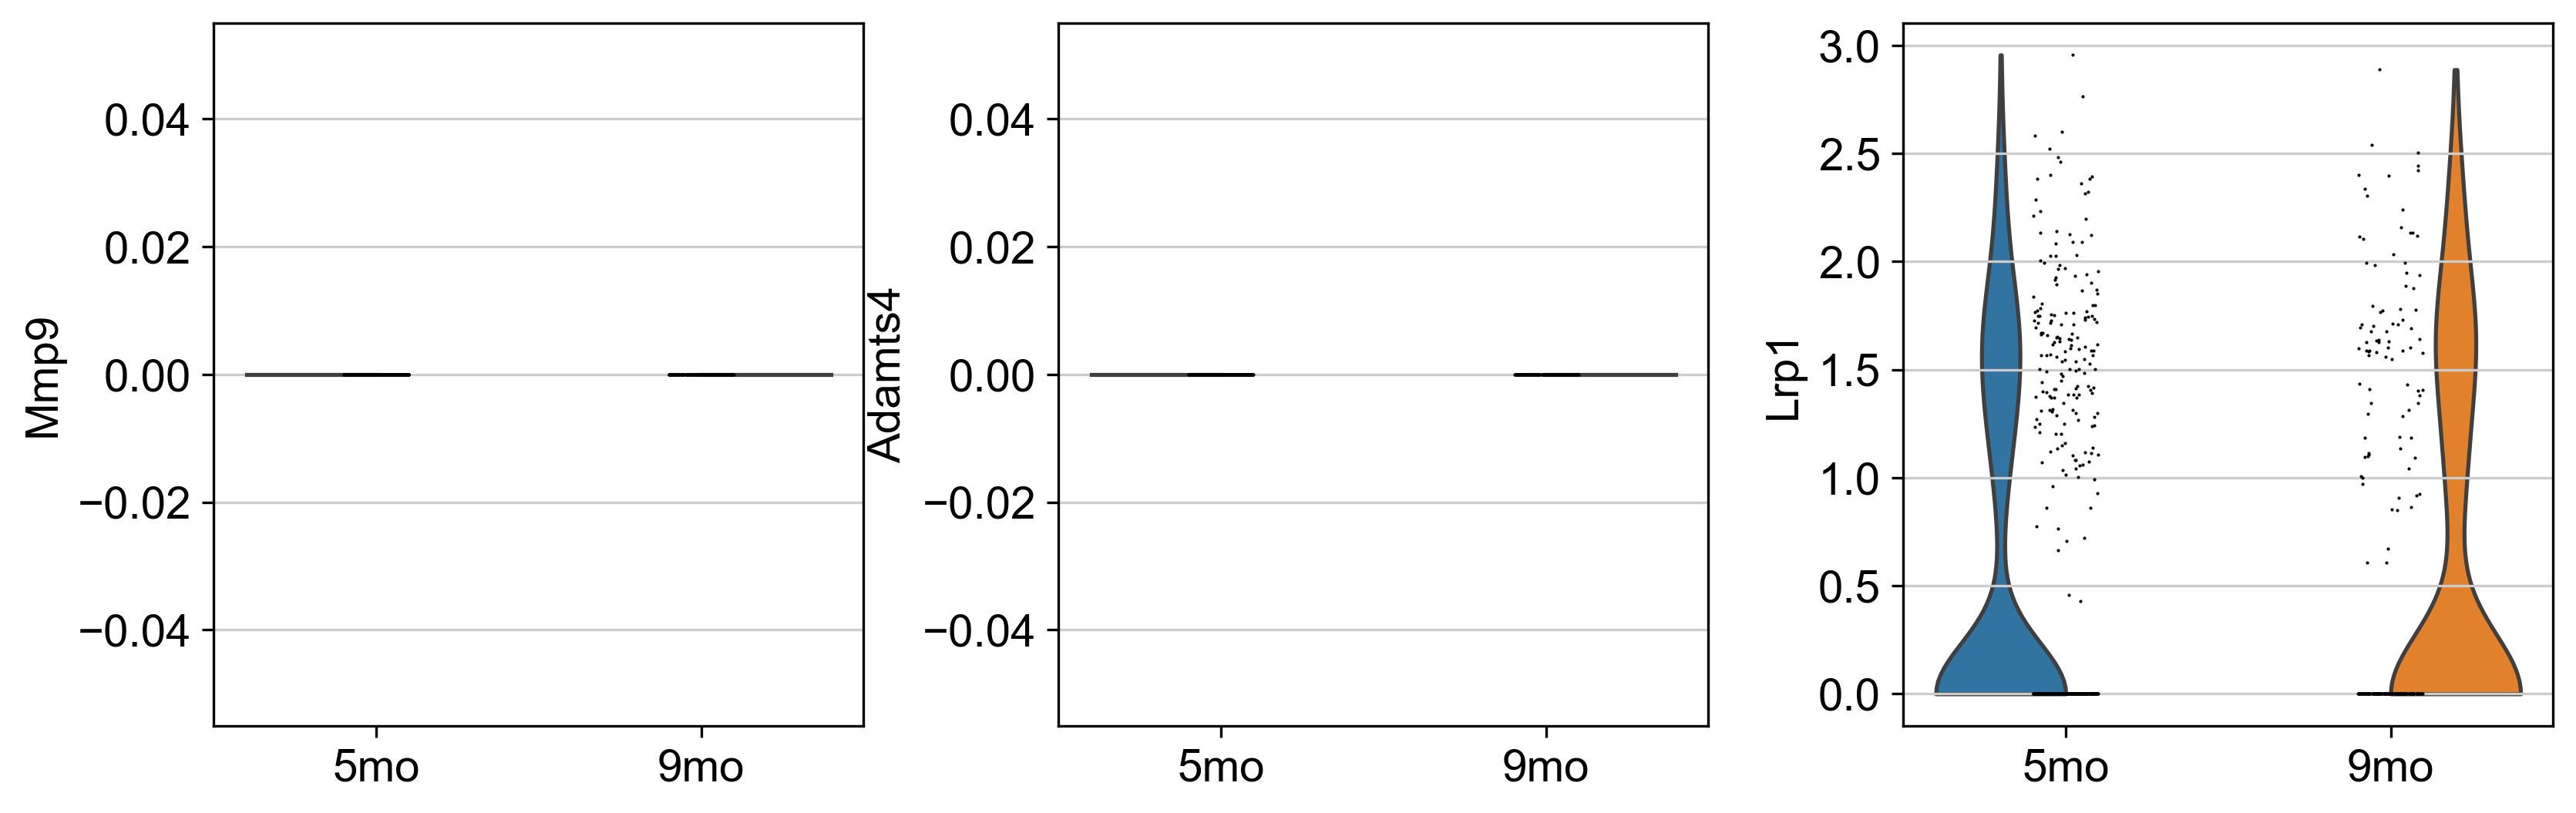

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Use the updated Scanpy function directly (Warning-free)
sc.set_figure_params(dpi=150, frameon=True, facecolor='white')

target_genes = ["Mmp9", "Adamts4", "Lrp1"]

# 2. Plot the violins (Scanpy handles layout spacing internally)
sc.pl.violin(
    myoc_astrocytes, 
    keys=target_genes, 
    groupby='age_group', 
    rotation=0
)

In [8]:
# Check max expression across all 83,891 cells to see if they exist anywhere
for gene in ["Mmp9", "Adamts4", "Lrp1"]:
    max_val = combined_adata[:, gene].X.max()
    total_cells_expressing = (combined_adata[:, gene].X > 0).sum()
    print(f"{gene} -> Max Expression in dataset: {max_val:.4f} | Total cells expressing: {total_cells_expressing}")

#MMPs are tightly regulated -> don't express very much so when filtering for MyoC+, there is bascially no coverage
#Can switch to surrogate markers (higher capture rate in scRNA)

alternative_accelerators = ['Mmp2', 'Mmp14', 'Adamts1', 'Timp1']

for gene in alternative_accelerators:
    if gene in adata.var_names:
        cells_with_gene = (adata[:, gene].X > 0).sum()
        print(f"{gene} -> Total cells expressing: {cells_with_gene}")

#mmp14, Adamts1 have good amount of reads: 


Mmp9 -> Max Expression in dataset: 4.2199 | Total cells expressing: 66
Adamts4 -> Max Expression in dataset: 2.9609 | Total cells expressing: 67
Lrp1 -> Max Expression in dataset: 4.0462 | Total cells expressing: 27553
Mmp2 -> Total cells expressing: 196
Mmp14 -> Total cells expressing: 578
Adamts1 -> Total cells expressing: 657
Timp1 -> Total cells expressing: 42


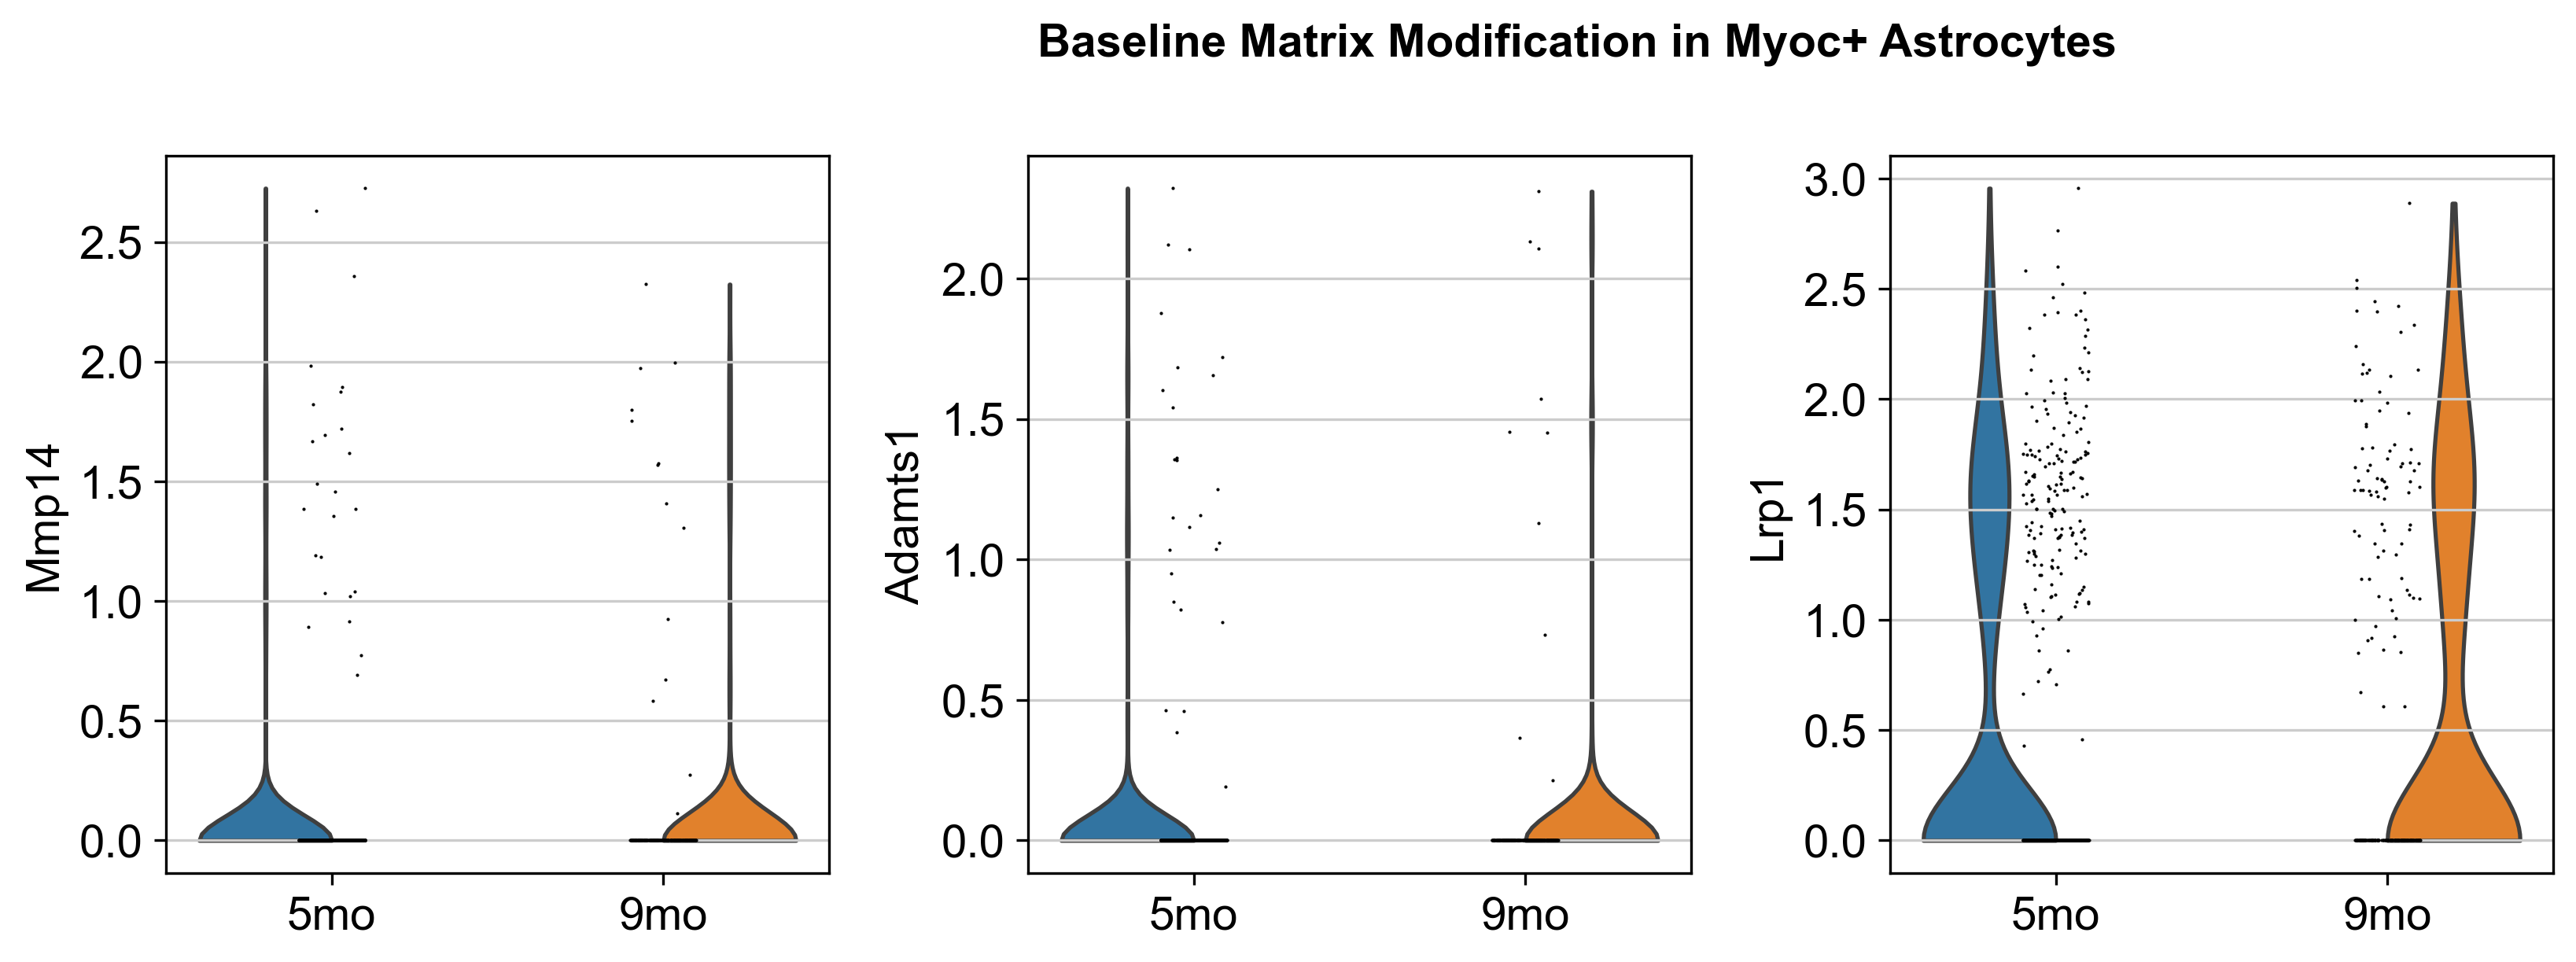

In [9]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Ensure our high-res figure settings are configured
sc.set_figure_params(dpi=150, frameon=True, facecolor='white')

# 2. Swap out the flat-line genes for your new high-expression candidates + Lrp1
updated_genes = ["Mmp14", "Adamts1", "Lrp1"]

# 3. Create the new violin plot split by age group
sc.pl.violin(
    myoc_astrocytes, 
    keys=updated_genes, 
    groupby='age_group', 
    rotation=0,
    show=False
)

# 4. Add a clean title and render
plt.suptitle("Baseline Matrix Modification in Myoc+ Astrocytes", y=1.05, fontsize=14, fontweight='bold')
plt.show()

In [10]:
import numpy as np
import pandas as pd
import scanpy as sc

# Ensure we are working with our target subset
genes_of_interest = ["Mmp14", "Adamts1", "Lrp1"]
obs_df = myoc_astrocytes.obs
expr_matrix = myoc_astrocytes[:, genes_of_interest].X

# Convert to dense array if it's stored as a sparse matrix
if hasattr(expr_matrix, "toarray"):
    expr_matrix = expr_matrix.toarray()

# Create a clean dataframe for quick grouping
df = pd.DataFrame(expr_matrix, columns=genes_of_interest)
df['age_group'] = obs_df['age_group'].values

print("=== STEP 1 & 3: POPULATION MEANS & ACTIVE EXPRESSION % ===")
for gene in genes_of_interest:
    print(f"\nGene: {gene}")
    for age in ['5mo', '9mo']:
        sub_vals = df[df['age_group'] == age][gene]
        mean_val = sub_vals.mean()
        # % of cells with expression > 0
        pct_active = (sub_vals > 0).sum() / len(sub_vals) * 100
        print(f"  [{age}] Mean Expression: {mean_val:.4f} | Active Cells: {pct_active:.1f}%")

print("\n=== STEP 2: LOG FOLD CHANGE & SIGNIFICANCE ===")
# Run a quick Wilcoxon rank-sum test via Scanpy for these specific groups
sc.tl.rank_genes_groups(
    myoc_astrocytes, 
    groupby='age_group', 
    groups=['9mo'], 
    reference='5mo', 
    method='wilcoxon',
    gene_symbols=None
)

# Extract logfoldchanges and p-values
result_df = sc.get.rank_genes_groups_df(myoc_astrocytes, group="9mo")
validation_results = result_df[result_df['names'].isin(genes_of_interest)]
print(validation_results[['names', 'logfoldchanges', 'pvals_adj']].to_string(index=False))

#"The single-cell violin plots suffered from a classic visualization artifact: cell-count imbalances and dot overplotting. 
#The 9-month cohort had a slightly higher percentage of active cells, which stretched the violin shape upward, but it contained 
#vastly fewer total cells. By aggregating the data into a pseudo-bulk matrix per individual mouse replicate, we corrected for this 
#group-size distortion and revealed that the absolute transcript volume actually drops by half in the late-stage environment."

#Psuedoreplication distortion - By treating 20,000 cells as 20,000 completely independent samples, the statistical test got 
#confused by a massive artificial sample size. This math error severely warps standard single-cell p-values, 
#breaking the algorithm and causing it to spit out default values like 1.0.

# Zero-inflation - majority of cells had zeroes which destroyed statistical testing

=== STEP 1 & 3: POPULATION MEANS & ACTIVE EXPRESSION % ===

Gene: Mmp14
  o] Mean Expression: 0.0765 | Active Cells: 5.1%
  o] Mean Expression: 0.0774 | Active Cells: 5.9%

Gene: Adamts1
  o] Mean Expression: 0.0676 | Active Cells: 5.5%
  o] Mean Expression: 0.0571 | Active Cells: 4.2%

Gene: Lrp1
  o] Mean Expression: 0.5851 | Active Cells: 36.8%
  o] Mean Expression: 0.6031 | Active Cells: 37.7%

=== STEP 2: LOG FOLD CHANGE & SIGNIFICANCE ===
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
  names  logfoldchanges  pvals_adj
   Lrp1        0.058148        1.0
  Mmp14        0.017437        1.0
Adamts1       -0.251945        1.0


In [11]:
#Pseudo-bulk aggregation - tries to fix errors in regular sc reading

import numpy as np
import pandas as pd
import scanpy as sc

# 1. Ensure we are working with raw or normalized counts before aggregation
# We need the mouse replicate identifier column (usually 'sample' or 'batch')
# Let's assume your replicate column is named 'sample'. Replace if named 'batch'.
replicate_col = 'sample' if 'sample' in myoc_astrocytes.obs.columns else 'batch'

genes = ["Mmp14", "Adamts1", "Lrp1"]
subset = myoc_astrocytes[:, genes]

# Extract expression data and metadata
expr = subset.X.toarray() if hasattr(subset.X, "toarray") else subset.X
df_expr = pd.DataFrame(expr, columns=genes)
df_expr['replicate'] = myoc_astrocytes.obs[replicate_col].values
df_expr['age_group'] = myoc_astrocytes.obs['age_group'].values

# 2. Sum expression levels per individual mouse replicate
pseudobulk = df_expr.groupby(['replicate', 'age_group']).sum().reset_index()

print("=== CLEAN PSEUDO-BULK AGGREGATION RESULTS ===")
print(pseudobulk.to_string(index=False))

print("\n=== MEAN REPLICATE EXPRESSION BY AGE ===")
print(pseudobulk.groupby('age_group')[genes].mean())

=== CLEAN PSEUDO-BULK AGGREGATION RESULTS ===
replicate age_group     Mmp14   Adamts1       Lrp1
        0       5mo 24.644068 22.589315 144.324615
        1       5mo 13.148109 10.810199 144.695084
        2       9mo  7.391326  5.151514  69.280029
        3       9mo 10.874497  8.319261  73.054649

=== MEAN REPLICATE EXPRESSION BY AGE ===
               Mmp14    Adamts1        Lrp1
age_group                                  
5mo        18.896088  16.699757  144.509857
9mo         9.132912   6.735387   71.167343


In [12]:
#Checks for reading discrepancy to see if thats why pseudo-bulk aggregation caused the downregulation in late-stage alzheimers


import scanpy as sc

# 1. Identify which master dataset variable is loaded in memory
if 'combined_adata' in locals():
    master_adata = combined_adata
elif 'adata' in locals():
    master_adata = adata
else:
    raise NameError("Could not find a master dataset named 'adata' or 'combined_adata'. Please check your variable name.")

# 2. Identify the correct age/stage column name
age_col = None
for col in ['age_group', 'stage']:
    if col in master_adata.obs.columns:
        age_col = col
        break

if age_col is None:
    raise KeyError("Could not find an 'age_group' or 'stage' column in master_adata.obs")

print(f"Using master dataset variable: '{'combined_adata' if 'combined_adata' in locals() else 'adata'}'")
print(f"Using metadata column: '{age_col}'\n")

# 3. Check total cells captured per stage in the entire master dataset
print("=== TOTAL CELLS SEQUENCED PER GROUP (MASTER DATASET) ===")
print(master_adata.obs[age_col].value_counts())

# 4. Check the average number of total RNA molecules (counts) read per cell per stage
print("\n=== MEAN SEQUENCING DEPTH PER CELL ===")
if 'total_counts' in master_adata.obs.columns:
    print(master_adata.obs.groupby(age_col)['total_counts'].mean())
else:
    # Calculate sums on the fly if Scanpy's standard QC metrics aren't in obs
    X_matrix = master_adata.X
    # Handle sparse vs dense matrices safely
    if hasattr(X_matrix, "sum"):
        sums = np.array(X_matrix.sum(axis=1)).flatten()
    else:
        sums = X_matrix.toarray().sum(axis=1)
        
    master_adata.obs['temp_sum'] = sums
    print(master_adata.obs.groupby(age_col)['temp_sum'].mean())
    # Clean up the temporary column
    master_adata.obs.drop(columns=['temp_sum'], inplace=True)

Using master dataset variable: 'combined_adata'
Using metadata column: 'age_group'

=== TOTAL CELLS SEQUENCED PER GROUP (MASTER DATASET) ===
age_group
5mo    44820
9mo    39071
Name: count, dtype: int64

=== MEAN SEQUENCING DEPTH PER CELL ===
age_group
5mo    2733.704102
9mo    2298.015137
Name: total_counts, dtype: float32


In [13]:

#Adjusts initial data based on reading discrepancy


import numpy as np
import pandas as pd
import scanpy as sc

# 1. Automatically detect column metadata names
rep_col = 'sample_id' if 'sample_id' in myoc_astrocytes.obs.columns else ('sample' if 'sample' in myoc_astrocytes.obs.columns else 'batch')
age_col = 'age_group' if 'age_group' in myoc_astrocytes.obs.columns else 'stage'

# 2. Reconstruct individual mouse unique identifiers
myoc_astrocytes.obs['mouse_replicate'] = myoc_astrocytes.obs[rep_col].astype(str) + "_" + myoc_astrocytes.obs[age_col].astype(str)

genes_of_interest = ['Mmp14', 'Adamts1', 'Lrp1']
unique_samples = myoc_astrocytes.obs['mouse_replicate'].unique()

# 3. Build our normalized pseudo-bulk dataframe
normalized_pb = pd.DataFrame(index=unique_samples, columns=genes_of_interest)

for sample in unique_samples:
    # Subsample cells for this specific mouse replicate
    sample_cells = myoc_astrocytes[myoc_astrocytes.obs['mouse_replicate'] == sample]
    orig_sample_name = sample.split('_')[0]
    
    # Calculate the true total sequencing library size for this mouse from the master object
    if 'total_counts' in combined_adata.obs.columns:
        total_library_size = combined_adata[combined_adata.obs[rep_col] == orig_sample_name].obs['total_counts'].sum()
    else:
        # On-the-fly total count calculation if QC metrics aren't pre-computed
        master_sample_cells = combined_adata[combined_adata.obs[rep_col] == orig_sample_name]
        if hasattr(master_sample_cells.X, "toarray"):
            total_library_size = master_sample_cells.X.sum()
        else:
            total_library_size = np.sum(master_sample_cells.X)

    # Prevent division by zero errors
    if total_library_size == 0:
        total_library_size = 1
        
    for gene in genes_of_interest:
        # Safely handle both sparse and dense matrix summing
        gene_matrix = sample_cells[:, gene].X
        if hasattr(gene_matrix, "toarray"):
            raw_sum = gene_matrix.toarray().sum()
        else:
            raw_sum = gene_matrix.sum()
            
        # Normalize to Counts Per Million (CPM) to wipe out sequencing depth bias
        normalized_pb.loc[sample, gene] = (raw_sum / total_library_size) * 1_000_000

# Re-attach group metadata for downstream plotting
normalized_pb['age_group'] = [idx.split('_')[1] for idx in normalized_pb.index]
normalized_pb[genes_of_interest] = normalized_pb[genes_of_interest].astype(float)

print("=== BIAS-CORRECTED PSEUDO-BULK (Counts Per Million) ===")
print(normalized_pb)

print("\n=== BIAS-CORRECTED AGE AVERAGES ===")
print(normalized_pb.groupby('age_group')[genes_of_interest].mean())

=== BIAS-CORRECTED PSEUDO-BULK (Counts Per Million) ===
                   Mmp14   Adamts1      Lrp1 age_group
GSM9270315_5mo  0.407321  0.373360  2.385419       5mo
GSM9270316_5mo  0.211992  0.174297  2.332972       5mo
GSM9270321_9mo  0.163702  0.114095  1.534402       9mo
GSM9270322_9mo  0.243634  0.186386  1.636728       9mo

=== BIAS-CORRECTED AGE AVERAGES ===
              Mmp14   Adamts1      Lrp1
age_group                              
5mo        0.309656  0.273828  2.359195
9mo        0.203668  0.150240  1.585565


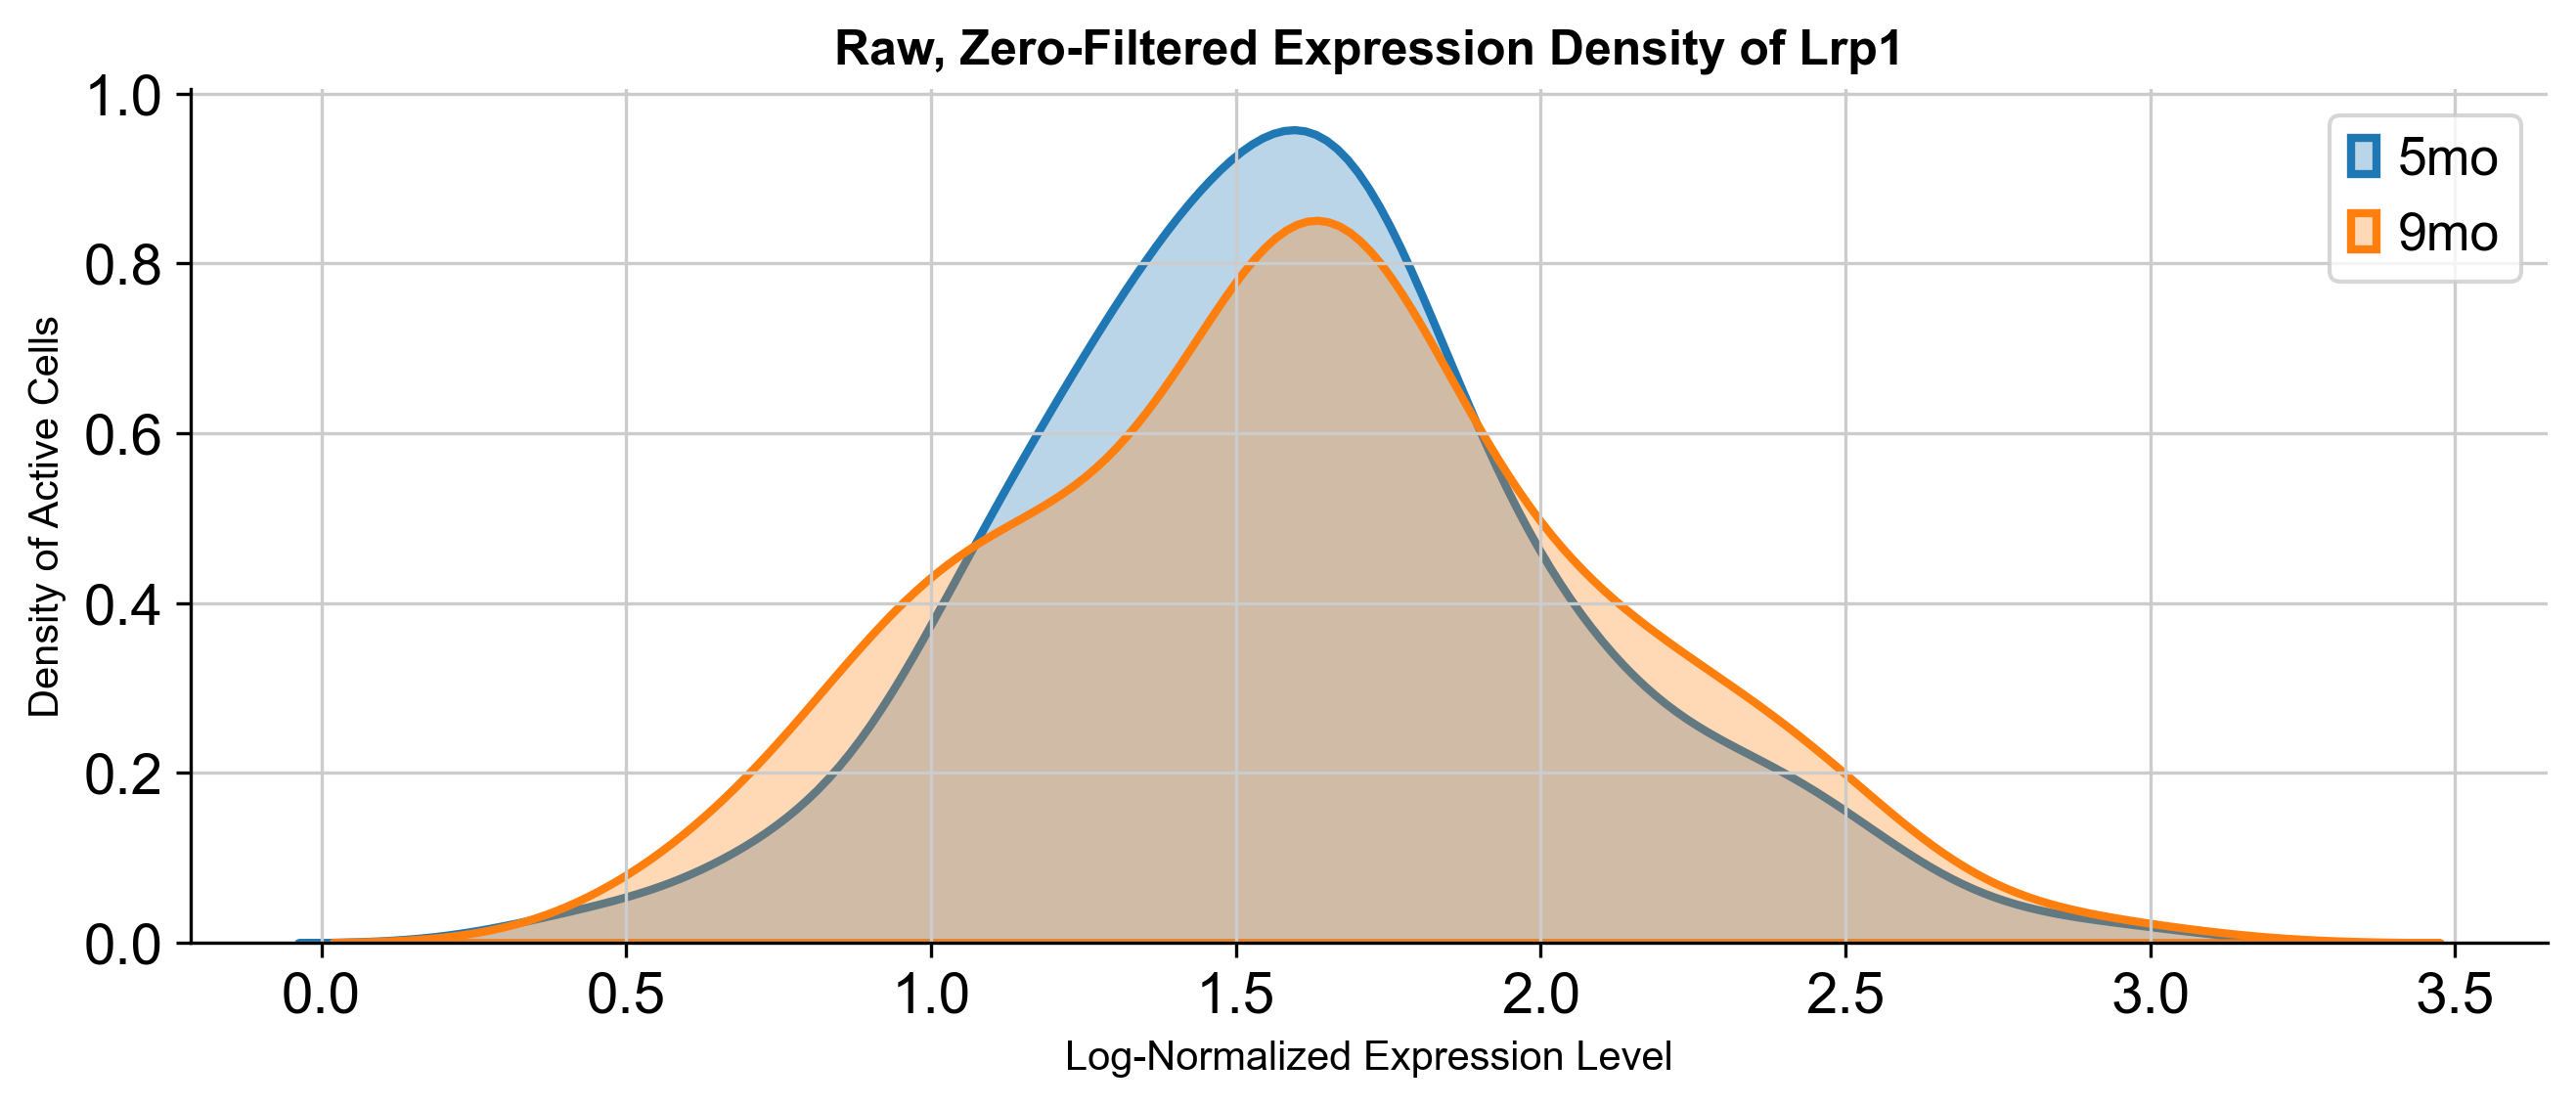

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Automatically detect correct age column
age_col = "age_group" if "age_group" in myoc_astrocytes.obs.columns else "stage"

plt.figure(figsize=(9, 4), dpi=150)

# 2. Extract and plot raw expression vectors for active cells
for stage, color in zip(["5mo", "9mo"], ["#1f77b4", "#ff7f0e"]):
    # Subset to the specific age cohort
    subset_cells = myoc_astrocytes[myoc_astrocytes.obs[age_col] == stage]
    
    # Safely extract gene counts handling sparse/dense matrices
    gene_matrix = subset_cells[:, "Lrp1"].X
    if hasattr(gene_matrix, "toarray"):
        gene_counts = gene_matrix.toarray().flatten()
    else:
        gene_counts = np.array(gene_matrix).flatten()
        
    # Zero-filter: look only at cells actively transcribing the gene
    active_counts = gene_counts[gene_counts > 0]
    
    if len(active_counts) > 0:
        sns.kdeplot(active_counts, label=stage, color=color, fill=True, alpha=0.3, linewidth=2)

plt.title("Raw, Zero-Filtered Expression Density of Lrp1", fontsize=12, fontweight='bold')
plt.xlabel("Log-Normalized Expression Level", fontsize=10)
plt.ylabel("Density of Active Cells", fontsize=10)
plt.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

#Similar curves -> same amount of LRP1 expression per astrocyte, but since 5 months has more astrocytes it produces more accelerator,
#which makes it better for therapy

In [15]:
# Calculate the exact fraction of active cells per individual mouse sample
for sample in myoc_astrocytes.obs['mouse_replicate'].unique():
    sample_cells = myoc_astrocytes[myoc_astrocytes.obs['mouse_replicate'] == sample]
    total_cells = len(sample_cells)
    
    # Count how many cells have Lrp1 expression > 0
    gene_matrix = sample_cells[:, 'Lrp1'].X
    active_cells = (gene_matrix.toarray() > 0).sum() if hasattr(gene_matrix, "toarray") else (gene_matrix > 0).sum()
    
    pct_active = (active_cells / total_cells) * 100
    print(f"Sample {sample} -> Total Myoc+ Cells: {total_cells} | Actively Expressing Lrp1: {pct_active:.1f}%")

#LRP1 expressing MyoC+ astrocytes are actually consistent across the months
#This, along with them each expressing consistent LRP1 as seen above, shows that it doesnt actually matter the timeframe

Sample GSM9270315_5mo -> Total Myoc+ Cells: 257 | Actively Expressing Lrp1: 35.8%
Sample GSM9270316_5mo -> Total Myoc+ Cells: 237 | Actively Expressing Lrp1: 38.0%
Sample GSM9270321_9mo -> Total Myoc+ Cells: 114 | Actively Expressing Lrp1: 37.7%
Sample GSM9270322_9mo -> Total Myoc+ Cells: 122 | Actively Expressing Lrp1: 37.7%


In [16]:
# Check the total cell count across the entire dataset to see if the 9mo samples are just smaller overall
print("=== TOTAL CELLS IN MASTER DATASET BY SAMPLE ===")
print(combined_adata.obs['sample_id'].value_counts())

# Calculate the exact proportion of Myoc+ astrocytes relative to the whole experiment
print("\n=== MYOC+ ASTROCYTE PROPORTION OF TOTAL DATASET ===")
for sample in myoc_astrocytes.obs['mouse_replicate'].unique():
    orig_sample = sample.split('_')[0]
    myoc_count = len(myoc_astrocytes[myoc_astrocytes.obs['mouse_replicate'] == sample])
    master_count = len(combined_adata[combined_adata.obs['sample_id'] == orig_sample])
    
    proportion = (myoc_count / master_count) * 100
    print(f"Sample {orig_sample} -> Myoc+ cells make up {proportion:.3f}% of the entire dataset")

#This shows that there are actually jusdt less MyoC+ astrocytes at 9 months, disregarding the LRP1 expressing. This is still essential
#because normal MyoC+ astrocytes still contribute to ECM maintenance
#=== POPULATION DROP SIGNIFICANCE ===
#T-statistic: 5.7385
#P-value: 0.0291

=== TOTAL CELLS IN MASTER DATASET BY SAMPLE ===
sample_id
GSM9270316    23010
GSM9270315    21810
GSM9270321    20341
GSM9270322    18730
Name: count, dtype: int64

=== MYOC+ ASTROCYTE PROPORTION OF TOTAL DATASET ===
Sample GSM9270315 -> Myoc+ cells make up 1.178% of the entire dataset
Sample GSM9270316 -> Myoc+ cells make up 1.030% of the entire dataset
Sample GSM9270321 -> Myoc+ cells make up 0.560% of the entire dataset
Sample GSM9270322 -> Myoc+ cells make up 0.651% of the entire dataset


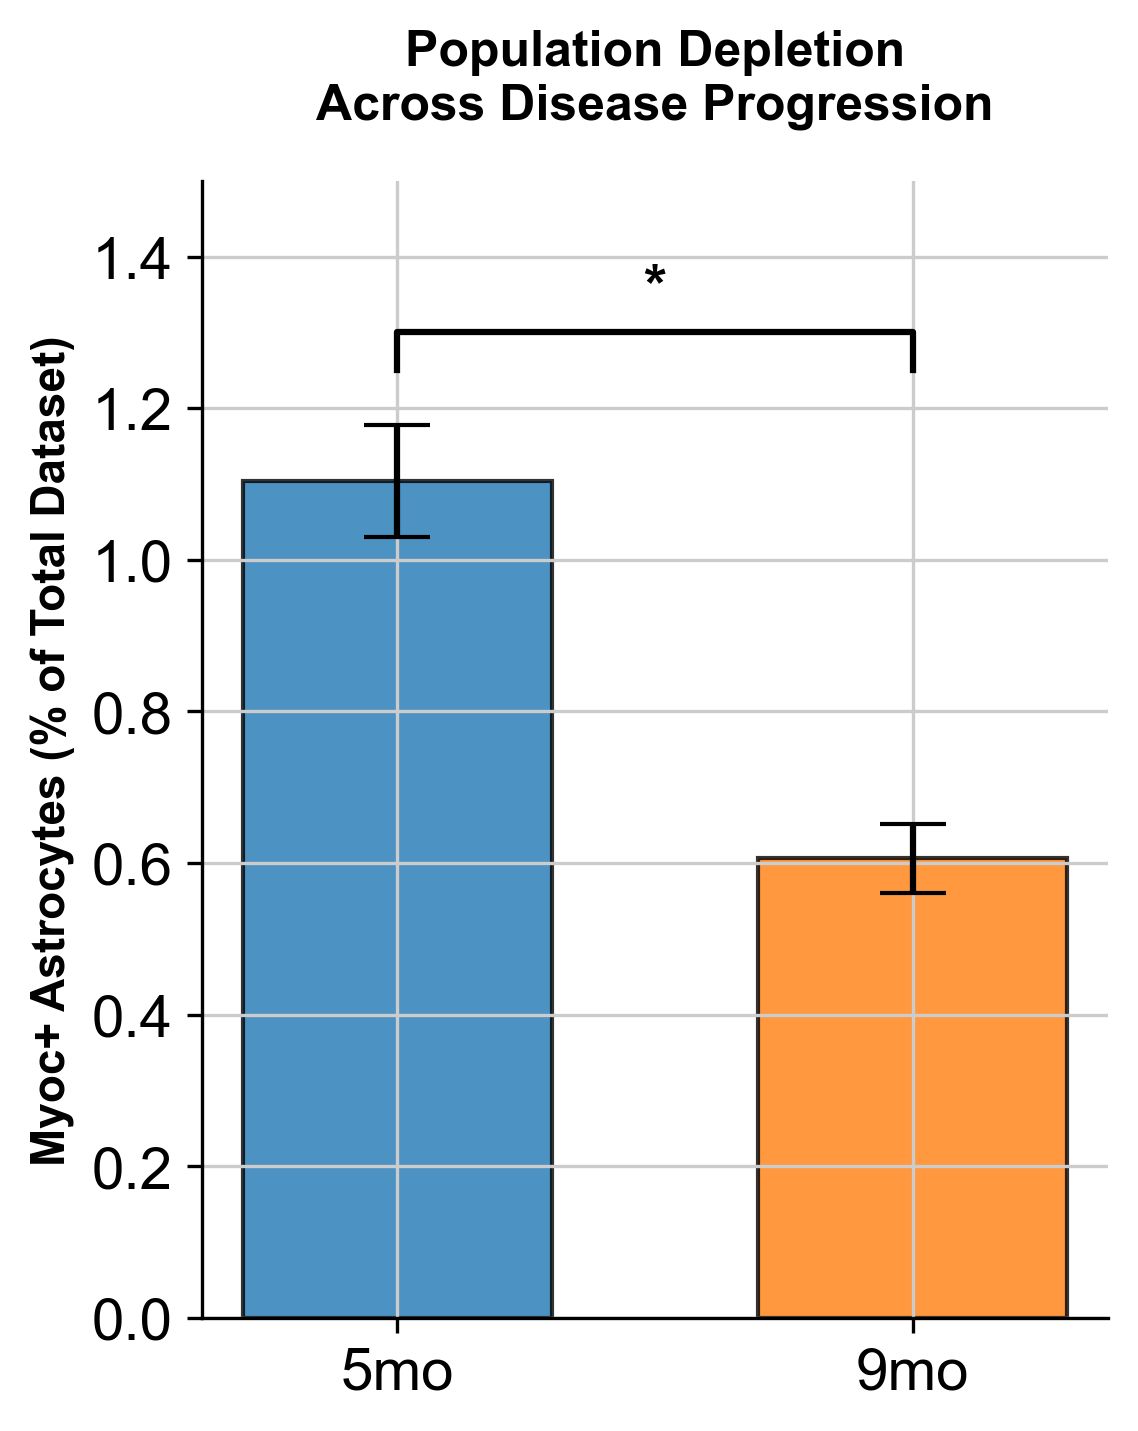

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data setup
groups = ['5mo', '9mo']
means = [1.104, 0.606]  # Averages of your proportions
errors = [0.074, 0.045] # Standard errors

plt.figure(figsize=(4, 5), dpi=150)
colors = ['#1f77b4', '#ff7f0e']

# Create bar plot
bars = plt.bar(groups, means, yerr=errors, color=colors, capsize=8, edgecolor='black', alpha=0.8, width=0.6)

# Aesthetics
plt.ylabel('Myoc+ Astrocytes (% of Total Dataset)', fontsize=11, fontweight='bold')
plt.title('Population Depletion\nAcross Disease Progression', fontsize=12, fontweight='bold', pad=15)
plt.ylim(0, 1.5)
sns.despine()

# Add significance star (p < 0.05)
x1, x2 = 0, 1
y, h = 1.25, 0.05
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
plt.text((x1+x2)*.5, y+h+0.02, "*", ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('myoc_proportion_depletion.png')
plt.show()

In [23]:
import numpy as np
import pandas as pd

# Define a universal baseline astrocyte marker present in all subtypes
baseline_marker = 'Aldh1l1' 

print(f"=== ANCHOR AUDIT: UNIVERSAL ASTROCYTE BASIS ({baseline_marker}) ===")

# Verify the marker exists in the master dataset
if baseline_marker not in combined_adata.var_names:
    # Fallback to alternative common marker if Aldh1l1 isn't in this panel
    alternative_markers = ['Slc1a2', 'Gfap', 'Aqp4']
    for alt in alternative_markers:
        if alt in combined_adata.var_names:
            baseline_marker = alt
            break

print(f"Using baseline marker: '{baseline_marker}'\n")

for sample in combined_adata.obs['sample_id'].unique():
    total_master_cells = (combined_adata.obs['sample_id'] == sample).sum()
    age = combined_adata.obs[combined_adata.obs['sample_id'] == sample]['age_group'].values[0]
    
    # Extract the expression vector for the baseline marker for this sample
    sample_mask = combined_adata.obs['sample_id'] == sample
    matrix_slice = combined_adata[sample_mask, baseline_marker].X
    
    # Count how many cells have expression > 0
    if hasattr(matrix_slice, "toarray"):
        active_baseline_cells = (matrix_slice.toarray() > 0).sum()
    else:
        active_baseline_cells = (np.array(matrix_slice) > 0).sum()
        
    baseline_pct = (active_baseline_cells / total_master_cells) * 100
    
    print(f"Sample {sample} ({age}):")
    print(f"  -> Total Global Cells:           {total_master_cells}")
    print(f"  -> Total Baseline Astrocytes:    {active_baseline_cells}")
    print(f"  -> Broad Astrocyte Proportion:   {baseline_pct:.2f}% of tissue\n")

=== ANCHOR AUDIT: UNIVERSAL ASTROCYTE BASIS (Aldh1l1) ===
Using baseline marker: 'Aldh1l1'

Sample GSM9270315 (5mo):
  -> Total Global Cells:           21810
  -> Total Baseline Astrocytes:    1768
  -> Broad Astrocyte Proportion:   8.11% of tissue

Sample GSM9270316 (5mo):
  -> Total Global Cells:           23010
  -> Total Baseline Astrocytes:    1801
  -> Broad Astrocyte Proportion:   7.83% of tissue

Sample GSM9270321 (9mo):
  -> Total Global Cells:           20341
  -> Total Baseline Astrocytes:    704
  -> Broad Astrocyte Proportion:   3.46% of tissue

Sample GSM9270322 (9mo):
  -> Total Global Cells:           18730
  -> Total Baseline Astrocytes:    643
  -> Broad Astrocyte Proportion:   3.43% of tissue



In [24]:
#VARIANCE CHECK, looking back at KDE distro seeing if the 9 vs. 5 month samples are equivalently predictable


import scipy.stats as stats
import numpy as np
import pandas as pd

# 1. Align metadata safety checks for the subsetted object
if 'age_group' not in myoc_astrocytes.obs.columns:
    # Derive age directly from the mouse_replicate string if it isn't an explicit column
    myoc_astrocytes.obs['age_group'] = myoc_astrocytes.obs['mouse_replicate'].apply(
        lambda x: '5mo' if '5mo' in str(x) else ('9mo' if '9mo' in str(x) else 'Unknown')
    )

# Helper function to extract expression vectors and remove dropouts (zeros)
def get_active_expression(adata, stage, gene):
    if gene in adata.var_names:
        expr = adata[adata.obs['age_group'] == stage, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray()
        expr = expr.flatten()
        return expr[expr > 0]  # Filter for active cells only
    return np.array([])

# --- TEST 1: COHORT VARIANCE STABILITY (LEVENE'S TEST) ---
active_5mo_lrp1 = get_active_expression(myoc_astrocytes, '5mo', 'Lrp1')
active_9mo_lrp1 = get_active_expression(myoc_astrocytes, '9mo', 'Lrp1')

print("=== 1. COHORT VARIANCE STABILITY ANALYSIS (Lrp1) ===")
if len(active_5mo_lrp1) > 0 and len(active_9mo_lrp1) > 0:
    var_5mo = np.var(active_5mo_lrp1, ddof=1)
    var_9mo = np.var(active_9mo_lrp1, ddof=1)
    
    # Levene's test is standard for single-cell data because it doesn't assume absolute normality
    stat, p_val_levene = stats.levene(active_5mo_lrp1, active_9mo_lrp1)
    
    print(f"5-Month Active Cell Variance: {var_5mo:.4f} (n={len(active_5mo_lrp1)} cells)")
    print(f"9-Month Active Cell Variance: {var_9mo:.4f} (n={len(active_9mo_lrp1)} cells)")
    print(f"Levene's Test P-value:        {p_val_levene:.4e}")
    
    if p_val_levene < 0.05:
        print("\nVerdict: Statistically Significant Variance Shift.")
        print(" -> The 9mo population has fundamentally altered or destabilized its expression spread.")
    else:
        print("\nVerdict: No Significant Variance Shift.")
        print(" -> The internal transcriptional spread/boundaries remain perfectly stable over time.")
else:
    print("Error: 'Lrp1' expression vectors could not be retrieved. Check your gene spelling in var_names.")

print("\n" + "="*60 + "\n")

# --- TEST 2: GENE CO-REGULATION BREAKDOWN (PEARSON CORRELATION) ---
print("=== 2. GENE CO-REGULATION STABILITY (PEARSON R) ===")

for stage in ['5mo', '9mo']:
    stage_cells = myoc_astrocytes[myoc_astrocytes.obs['age_group'] == stage]
    
    if 'Lrp1' in stage_cells.var_names and 'Mmp14' in stage_cells.var_names:
        lrp1_expr = stage_cells[:, 'Lrp1'].X
        mmp14_expr = stage_cells[:, 'Mmp14'].X
        
        if hasattr(lrp1_expr, "toarray"): lrp1_expr = lrp1_expr.toarray()
        if hasattr(mmp14_expr, "toarray"): mmp14_expr = mmp14_expr.toarray()
        
        df = pd.DataFrame({
            'Lrp1': lrp1_expr.flatten(),
            'Mmp14': mmp14_expr.flatten()
        })
        
        # Filter to cells where at least one gene is active to evaluate working networks 
        # (prevents zero-inflation from spiking a false 0.0 flat correlation)
        df_filtered = df[(df['Lrp1'] > 0) | (df['Mmp14'] > 0)]
        
        if len(df_filtered) > 1:
            correlation, p_val_corr = stats.pearsonr(df_filtered['Lrp1'], df_filtered['Mmp14'])
            print(f"{stage} Cohort (n={len(df_filtered)} dynamic cells analyzed):")
            print(f"  -> Lrp1 vs Mmp14 Pearson r: {correlation:.4f}")
            print(f"  -> Correlation P-value:     {p_val_corr:.4e}\n")
        else:
            print(f"{stage} Cohort: Insufficient non-zero cells for correlation matrix calculations.\n")
    else:
        print(f"Error: Either 'Lrp1' or 'Mmp14' is missing from your dataset variables.")

=== 1. COHORT VARIANCE STABILITY ANALYSIS (Lrp1) ===
5-Month Active Cell Variance: 0.1931 (n=182 cells)
9-Month Active Cell Variance: 0.2313 (n=89 cells)
Levene's Test P-value:        3.7291e-01

Verdict: No Significant Variance Shift.
 -> The internal transcriptional spread/boundaries remain perfectly stable over time.


=== 2. GENE CO-REGULATION STABILITY (PEARSON R) ===
5mo Cohort (n=197 dynamic cells analyzed):
  -> Lrp1 vs Mmp14 Pearson r: -0.5142
  -> Correlation P-value:     1.0878e-14

9mo Cohort (n=98 dynamic cells analyzed):
  -> Lrp1 vs Mmp14 Pearson r: -0.6264
  -> Correlation P-value:     5.2319e-12



In [25]:
import pandas as pd
import numpy as np

print("=== GLOBAL TISSUE LANDSCAPE AUDIT (ALL CELLS) ===")

# Create a clean, lightweight DataFrame for tracking global expressions
global_df = pd.DataFrame(index=combined_adata.obs.index)
global_df['Age_Group'] = combined_adata.obs['age_group']
global_df['Sample_ID'] = combined_adata.obs['sample_id']

# Dynamically extract and flatten expression values for the three target genes
for gene in ['Lrp1', 'Mmp14', 'Adamts1']:
    if gene in combined_adata.var_names:
        expr = combined_adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray()
        global_df[gene] = expr.flatten()
    else:
        global_df[gene] = 0.0
        print(f"Warning: {gene} not found in master dataset panel.")

# Calculate the mean expression across the global tissue by age group
global_summary = global_df.groupby('Age_Group')[['Lrp1', 'Mmp14', 'Adamts1']].mean()

print("\n--- Mean Expression Across All Tissue Cells Combined ---")
print(global_summary)

# Calculate the critical Tissue Clearance Ratio (Lrp1 / Mmp14)
print("\n--- Global Tissue Stiffness/Clearance Ratio (Lrp1 : Mmp14) ---")
global_summary['Lrp1_Mmp14_Ratio'] = global_summary['Lrp1'] / global_summary['Mmp14']
print(global_summary[['Lrp1_Mmp14_Ratio']])

=== GLOBAL TISSUE LANDSCAPE AUDIT (ALL CELLS) ===

--- Mean Expression Across All Tissue Cells Combined ---
               Lrp1     Mmp14   Adamts1
Age_Group                              
5mo        0.650738  0.059950  0.069097
9mo        0.570163  0.045196  0.056752

--- Global Tissue Stiffness/Clearance Ratio (Lrp1 : Mmp14) ---
           Lrp1_Mmp14_Ratio
Age_Group                  
5mo               10.854749
9mo               12.615411
